<a href="https://colab.research.google.com/github/SebasFru/Terminal-de-Economia./blob/main/Proyecto_Final_Eco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd
import numpy as np
import plotly.express as px

Descargamos y visualizamos la base de datos principal, donde se encuentra la informacion de los créditos y sus calificaciones.

In [80]:
df_principal = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Proyecto/040_R04A_417_10.csv')

In [81]:
df_principal.head(3)

,sector,periodo,institucion,moneda,tipo_saldo,orden_presentacion,concepto,importe_pesos
0,40,202501,40002,14,10,10,101800103003,-1.024114e+10
1,40,202501,40002,4,10,10,101800103003,-5.785247e+08
2,40,202501,40002,14,10,20,111800304005,-4.978340e+09


Descargamos y visualizamos la base de datos la información de las intituciones, su clave de institución y grupo.

In [82]:
df_instituciones = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Proyecto/catalogo_instituciones_BM (1).csv", encoding='latin-1')

In [83]:
df_instituciones.head(3)

,clavesector,sector,claveinstitucion,nombreinstitucion,clavegrupo,nombregrupo
0,40,BANCA MÚLTIPLE,40002,Banamex,59.0,G-7
1,40,BANCA MÚLTIPLE,40012,BBVA México,59.0,G-7
2,40,BANCA MÚLTIPLE,40014,Santander,59.0,G-7


En esta otra vace de datos se encuentran la descripcion asociada a los conceptos del df_principal.

In [84]:
df_claves = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Proyecto/catalogo_R04A_417_BM (1).csv", encoding='latin-1')

In [85]:
df_claves.head(3)

,concepto,descripcion,descripcion_identada,orden
0,101800103003,Estimaciones totales (I+II+III+IV),Estimaciones totales (I+II+III+IV),10
1,111800304005,I. Cartera base y estimaciones derivadas de la...,I. Cartera base y estimaciones derivadas de l...,20
2,101800505014,A). Cartera de crédito,A). Cartera de crédito,30


Debido a que la base de datos de conceptos no esta identada correctamente, tuvimos que estructurar todo nuevamente, analizando la base de datso tenemos que esta de la sigueinte forma:


[Niveles y Jerarquias](https://drive.google.com/file/d/1oce3Qxbl1X8nBJt3p9emInyJvY4geGi6/view?usp=drive_link)

In [86]:
def reestructurar_catalogo_colab(df):
    def determinar_nivel(descripcion):
        if pd.isna(descripcion):
            return 0
        desc = str(descripcion).strip()
        if desc.startswith("Estimaciones totales"):
            return 1
        elif desc.startswith(("I. ", "II. ", "III. ", "IV. ")):
            return 2
        elif desc.startswith(("A). ", "B). ")):
            return 3
        elif desc.startswith(("1. ", "2. ", "3. ")):
            return 4
        elif any(x in desc for x in ["Actividad", "Operaciones", "Entidades"]):
            return 5
        elif any(x in desc for x in ["Tarjeta", "Personales", "Nómina", "Media"]):
            return 6
        elif desc.startswith("Riesgo"):
            return 7
        elif desc == "Piso MI":
            return 8
        else:
            return 4
    df['nivel_corregido'] = df['descripcion'].apply(determinar_nivel)
    for i in range(1, 9):
        df[f'Nivel_{i}'] = None

    current_path = {}

    for idx, row in df.iterrows():
        nivel = row['nivel_corregido']
        if nivel == 0:
            continue
        current_path[nivel] = row['descripcion']

        # Limpiar niveles inferiores
        for l in range(nivel + 1, 9):
            current_path.pop(l, None)


        for l in range(1, nivel + 1):
            if l in current_path:
                df.at[idx, f'Nivel_{l}'] = current_path[l]

    nombres_niveles = {
        'Nivel_1': 'Agregado_Total',
        'Nivel_2': 'Etapa_Riesgo',
        'Nivel_3': 'Tipo_Operacion',
        'Nivel_4': 'Clase_Credito',
        'Nivel_5': 'Subclase_Credito',
        'Nivel_6': 'Especificacion_Producto',
        'Nivel_7': 'Calificacion_Riesgo',
        'Nivel_8': 'Piso_Minimo'
    }

    df = df.rename(columns=nombres_niveles)

    columnas_finales = [
        'concepto', 'descripcion', 'orden', 'nivel_corregido',
        'Agregado_Total', 'Etapa_Riesgo', 'Tipo_Operacion',
        'Clase_Credito', 'Subclase_Credito', 'Especificacion_Producto',
        'Calificacion_Riesgo', 'Piso_Minimo'
    ]

    columnas_existentes = [col for col in columnas_finales if col in df.columns]
    print("\n🔍 Vista previa de la estructura reordenada:")
    display(df[columnas_existentes].head(10))

    return df
if 'df_claves' in globals():
    print("📂 DataFrame 'df_claves' encontrado. Iniciando reestructuración...")
    df_reestructurado = reestructurar_catalogo_colab(df_claves.copy())
else:
    print("❌ Error: No se encontró el DataFrame 'df_claves'")
    print("Por favor asegúrate de que el DataFrame está cargado correctamente")

📂 DataFrame 'df_claves' encontrado. Iniciando reestructuración...

🔍 Vista previa de la estructura reordenada:


,concepto,descripcion,orden,nivel_corregido,Agregado_Total,Etapa_Riesgo,Tipo_Operacion,Clase_Credito,Subclase_Credito,Especificacion_Producto,Calificacion_Riesgo,Piso_Minimo
0,101800103003,Estimaciones totales (I+II+III+IV),10,1,Estimaciones totales (I+II+III+IV),None,None,None,None,None,None,None
1,111800304005,I. Cartera base y estimaciones derivadas de la...,20,2,Estimaciones totales (I+II+III+IV),I. Cartera base y estimaciones derivadas de la...,None,None,None,None,None,None
2,101800505014,A). Cartera de crédito,30,3,Estimaciones totales (I+II+III+IV),I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,None,None,None,None,None
3,101801406055,1. Créditos comerciales,40,4,Estimaciones totales (I+II+III+IV),I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,1. Créditos comerciales,None,None,None,None
4,101808208113,Actividad empresarial o comercial,50,5,Estimaciones totales (I+II+III+IV),I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,1. Créditos comerciales,Actividad empresarial o comercial,None,None,None
5,101811309053,Operaciones quirografarias,60,5,Estimaciones totales (I+II+III+IV),I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,1. Créditos comerciales,Operaciones quirografarias,None,None,None
6,101805310001,Créditos en cuenta corriente,70,4,Estimaciones totales (I+II+III+IV),I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,None,None
7,111800111049,Riesgo A-1,80,7,Estimaciones totales (I+II+III+IV),I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-1,None
8,111800111050,Riesgo A-2,90,7,Estimaciones totales (I+II+III+IV),I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-2,None
9,111800111051,Riesgo B-1,100,7,Estimaciones totales (I+II+III+IV),I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-1,None


Unimos df_principal, df_instituciones y  df_claves segun la clave de institución y concepto respectivamente.

In [87]:
# Unir df_principal con df_instituciones en base a 'institucion' y 'claveinstitucion'
df_resultado = df_principal.merge(df_instituciones,
                                  left_on='institucion',
                                  right_on='claveinstitucion',
                                  how='left')

# Unir df_resultado con df_claves en base a 'concepto'
df_resultado = df_resultado.merge(df_reestructurado,
                                  on='concepto',
                                  how='left')

In [88]:
df_resultado.head(6)

,sector_x,periodo,institucion,moneda,tipo_saldo,orden_presentacion,concepto,importe_pesos,clavesector,sector_y,...,orden,nivel_corregido,Agregado_Total,Etapa_Riesgo,Tipo_Operacion,Clase_Credito,Subclase_Credito,Especificacion_Producto,Calificacion_Riesgo,Piso_Minimo
0,40,202501,40002,14,10,10,101800103003,-1.024114e+10,40,BANCA MÚLTIPLE,...,10,1,Estimaciones totales (I+II+III+IV),None,None,None,None,None,None,None
1,40,202501,40002,4,10,10,101800103003,-5.785247e+08,40,BANCA MÚLTIPLE,...,10,1,Estimaciones totales (I+II+III+IV),None,None,None,None,None,None,None
2,40,202501,40002,14,10,20,111800304005,-4.978340e+09,40,BANCA MÚLTIPLE,...,20,2,Estimaciones totales (I+II+III+IV),I. Cartera base y estimaciones derivadas de la...,None,None,None,None,None,None
3,40,202501,40002,4,10,20,111800304005,-3.159043e+08,40,BANCA MÚLTIPLE,...,20,2,Estimaciones totales (I+II+III+IV),I. Cartera base y estimaciones derivadas de la...,None,None,None,None,None,None
4,40,202501,40002,14,10,30,101800505014,-4.968993e+09,40,BANCA MÚLTIPLE,...,30,3,Estimaciones totales (I+II+III+IV),I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,None,None,None,None,None
5,40,202501,40002,4,10,30,101800505014,-3.145321e+08,40,BANCA MÚLTIPLE,...,30,3,Estimaciones totales (I+II+III+IV),I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,None,None,None,None,None


Empezamos por analizar algunas de las columnas.

In [89]:
df_resultado.value_counts("Calificacion_Riesgo")

,count
Calificacion_Riesgo,
Riesgo E,806450
Riesgo A-1,408778
Riesgo D,407414
Riesgo A-2,407078
Riesgo C-1,406581
Riesgo B-3,406551
Riesgo C-2,406549
Riesgo B-1,406355
Riesgo B-2,406025


In [90]:
df_resultado.columns

Index(['sector_x', 'periodo', 'institucion', 'moneda', 'tipo_saldo',
       'orden_presentacion', 'concepto', 'importe_pesos', 'clavesector',
       'sector_y', 'claveinstitucion', 'nombreinstitucion', 'clavegrupo',
       'nombregrupo', 'descripcion', 'descripcion_identada', 'orden',
       'nivel_corregido', 'Agregado_Total', 'Etapa_Riesgo', 'Tipo_Operacion',
       'Clase_Credito', 'Subclase_Credito', 'Especificacion_Producto',
       'Calificacion_Riesgo', 'Piso_Minimo'],
      dtype='object')

In [91]:
df_resultado.describe()

,sector_x,periodo,institucion,moneda,tipo_saldo,orden_presentacion,concepto,importe_pesos,clavesector,claveinstitucion,clavegrupo,orden,nivel_corregido
count,4664256.0,4.664256e+06,4.664256e+06,4.664256e+06,4664256.0,4.664256e+06,4.664256e+06,4.664256e+06,4664256.0,4.664256e+06,4.541416e+06,4.664256e+06,4.664256e+06
mean,40.0,2.023132e+05,3.905729e+04,9.052390e+00,10.0,8.350954e+03,1.106115e+11,-1.954334e+07,40.0,3.905729e+04,6.181327e+01,8.350954e+03,6.736958e+00
std,0.0,8.692867e+01,6.422913e+03,4.999726e+00,0.0,4.838274e+03,3.247225e+09,7.759316e+08,0.0,6.422913e+03,1.627351e+00,4.838274e+03,1.016071e+00
min,40.0,2.022010e+05,5.000000e+00,4.000000e+00,10.0,1.000000e+01,1.018001e+11,-2.116276e+11,40.0,5.000000e+00,5.900000e+01,1.000000e+01,1.000000e+00
25%,40.0,2.022100e+05,4.007200e+04,4.000000e+00,10.0,4.120000e+03,1.118021e+11,0.000000e+00,40.0,4.007200e+04,6.100000e+01,4.120000e+03,7.000000e+00
50%,40.0,2.023070e+05,4.013200e+04,1.400000e+01,10.0,8.380000e+03,1.118099e+11,0.000000e+00,40.0,4.013200e+04,6.200000e+01,8.380000e+03,7.000000e+00
75%,40.0,2.024050e+05,4.015000e+04,1.400000e+01,10.0,1.253000e+04,1.118122e+11,0.000000e+00,40.0,4.015000e+04,6.300000e+01,1.253000e+04,7.000000e+00
max,40.0,2.025010e+05,4.016900e+04,1.400000e+01,10.0,1.671000e+04,1.118257e+11,4.405323e+06,40.0,4.016900e+04,6.400000e+01,1.671000e+04,8.000000e+00


In [92]:
df_resultado['sector_x'].value_counts()

,count
sector_x,
40,4664256


In [93]:

df_resultado['clavesector'].value_counts()

,count
clavesector,
40,4664256


In [94]:
df_resultado['tipo_saldo'].value_counts()

,count
tipo_saldo,
10,4664256


Eliminamos las columnas que no tienen datos relevantes.

In [95]:
df_resultado.drop(columns=['sector_x','clavesector','tipo_saldo','descripcion_identada',
    'orden_presentacion',
    'concepto',
    'claveinstitucion',
    'orden','institucion','sector_y','clavegrupo','descripcion','Agregado_Total'], inplace=True)

In [96]:
df_resultado.head(2)

,periodo,moneda,importe_pesos,nombreinstitucion,nombregrupo,nivel_corregido,Etapa_Riesgo,Tipo_Operacion,Clase_Credito,Subclase_Credito,Especificacion_Producto,Calificacion_Riesgo,Piso_Minimo
0,202501,14,-1.024114e+10,Banamex,G-7,1,None,None,None,None,None,None,None
1,202501,4,-5.785247e+08,Banamex,G-7,1,None,None,None,None,None,None,None


In [97]:
df_resultado.columns

Index(['periodo', 'moneda', 'importe_pesos', 'nombreinstitucion',
       'nombregrupo', 'nivel_corregido', 'Etapa_Riesgo', 'Tipo_Operacion',
       'Clase_Credito', 'Subclase_Credito', 'Especificacion_Producto',
       'Calificacion_Riesgo', 'Piso_Minimo'],
      dtype='object')

En la documentación encontramos que la variable modenda tiene 3 valores que significan:

    2: "Moneda extranjera en dólares", la cual vamos a expresar como USD.
    4: "Moneda extranjera en pesos", la cual vamos a expresar como "ME"
    14: "Moneda nacional, VSM, UMA y UDIS en pesos" la cual vamos a expresar como "MXN".

In [98]:

moneda_dict = {
    2: "USD",
    4: "ME",
    14: "MXN"
}

df_resultado['descripcion_moneda'] = df_resultado['moneda'].map(moneda_dict)

print(df_resultado[['moneda', 'descripcion_moneda']].drop_duplicates())

   moneda descripcion_moneda
0      14                MXN
1       4                 ME


In [99]:
df_resultado.drop(columns=['moneda'], inplace=True)

In [100]:
df_resultado.head(10)

,periodo,importe_pesos,nombreinstitucion,nombregrupo,nivel_corregido,Etapa_Riesgo,Tipo_Operacion,Clase_Credito,Subclase_Credito,Especificacion_Producto,Calificacion_Riesgo,Piso_Minimo,descripcion_moneda
0,202501,-1.024114e+10,Banamex,G-7,1,None,None,None,None,None,None,None,MXN
1,202501,-5.785247e+08,Banamex,G-7,1,None,None,None,None,None,None,None,ME
2,202501,-4.978340e+09,Banamex,G-7,2,I. Cartera base y estimaciones derivadas de la...,None,None,None,None,None,None,MXN
3,202501,-3.159043e+08,Banamex,G-7,2,I. Cartera base y estimaciones derivadas de la...,None,None,None,None,None,None,ME
4,202501,-4.968993e+09,Banamex,G-7,3,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,None,None,None,None,None,MXN
5,202501,-3.145321e+08,Banamex,G-7,3,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,None,None,None,None,None,ME
6,202501,-1.396596e+09,Banamex,G-7,4,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,1. Créditos comerciales,None,None,None,None,MXN
7,202501,-3.145321e+08,Banamex,G-7,4,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,1. Créditos comerciales,None,None,None,None,ME
8,202501,-2.832093e+08,Banamex,G-7,5,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,1. Créditos comerciales,Actividad empresarial o comercial,None,None,None,ME
9,202501,-7.914464e+08,Banamex,G-7,5,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,1. Créditos comerciales,Actividad empresarial o comercial,None,None,None,MXN


Cambiamos nombres.

In [101]:
# Definir el nuevo orden y nombres de las columnas
nuevo_orden = [
    'periodo',
    'nombreinstitucion',
    'nombregrupo',
    'importe_pesos',
    'descripcion moneda',
    'nivel corregido',
    'Etapa Riesgo',
    'Tipo Operacion',
    'Clase Credito',
    'Subclase Credito',
    'Especificacion Producto',
    'Calificacion Riesgo',
    'Piso Minimo'
]

# Diccionario para renombrar las columnas
nuevos_nombres = {
    'descripcion_moneda': 'descripcion moneda',
    'nivel_corregido': 'nivel corregido',
    'Etapa_Riesgo': 'Etapa Riesgo',
    'Tipo_Operacion': 'Tipo Operacion',
    'Clase_Credito': 'Clase Credito',
    'Subclase_Credito': 'Subclase Credito',
    'Especificacion_Producto': 'Especificacion Producto',
    'Calificacion_Riesgo': 'Calificacion Riesgo',
    'Piso_Minimo': 'Piso Minimo'
}

# Aplicar los cambios
df_final = df_resultado.rename(columns=nuevos_nombres)

# Reordenar las columnas (solo incluyendo las que existan)
columnas_finales = [col for col in nuevo_orden if col in df_final.columns]
df_final = df_final[columnas_finales]


In [102]:
df_final.head(5)

,periodo,nombreinstitucion,nombregrupo,importe_pesos,descripcion moneda,nivel corregido,Etapa Riesgo,Tipo Operacion,Clase Credito,Subclase Credito,Especificacion Producto,Calificacion Riesgo,Piso Minimo
0,202501,Banamex,G-7,-1.024114e+10,MXN,1,None,None,None,None,None,None,None
1,202501,Banamex,G-7,-5.785247e+08,ME,1,None,None,None,None,None,None,None
2,202501,Banamex,G-7,-4.978340e+09,MXN,2,I. Cartera base y estimaciones derivadas de la...,None,None,None,None,None,None
3,202501,Banamex,G-7,-3.159043e+08,ME,2,I. Cartera base y estimaciones derivadas de la...,None,None,None,None,None,None
4,202501,Banamex,G-7,-4.968993e+09,MXN,3,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,None,None,None,None,None


In [103]:
df_final.columns

Index(['periodo', 'nombreinstitucion', 'nombregrupo', 'importe_pesos',
       'descripcion moneda', 'nivel corregido', 'Etapa Riesgo',
       'Tipo Operacion', 'Clase Credito', 'Subclase Credito',
       'Especificacion Producto', 'Calificacion Riesgo', 'Piso Minimo'],
      dtype='object')

In [104]:
df_final.value_counts('Calificacion Riesgo')

,count
Calificacion Riesgo,
Riesgo E,806450
Riesgo A-1,408778
Riesgo D,407414
Riesgo A-2,407078
Riesgo C-1,406581
Riesgo B-3,406551
Riesgo C-2,406549
Riesgo B-1,406355
Riesgo B-2,406025


In [105]:
df_final.value_counts('Piso Minimo')

,count
Piso Minimo,
Piso MI,399564


Eliminamos los datos que no son creditos aprobados.
Estos al menos deben tener nivel 7, es decir, una calificación.

In [106]:
df_final = df_final[df_final['nivel corregido'] >= 7]

In [107]:
df_final.head(10)

,periodo,nombreinstitucion,nombregrupo,importe_pesos,descripcion moneda,nivel corregido,Etapa Riesgo,Tipo Operacion,Clase Credito,Subclase Credito,Especificacion Producto,Calificacion Riesgo,Piso Minimo
14,202501,Banamex,G-7,-2.250218e+08,MXN,7,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-1,None
15,202501,Banamex,G-7,-2.468053e+07,ME,7,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-1,None
16,202501,Banamex,G-7,-1.153210e+08,MXN,7,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-2,None
17,202501,Banamex,G-7,-9.164558e+06,ME,7,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-2,None
18,202501,Banamex,G-7,0.000000e+00,ME,7,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-1,None
19,202501,Banamex,G-7,-1.242725e+07,MXN,7,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-1,None
20,202501,Banamex,G-7,-7.484578e+06,ME,7,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-2,None
21,202501,Banamex,G-7,-6.449692e+06,MXN,7,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-2,None
22,202501,Banamex,G-7,0.000000e+00,ME,7,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-3,None
23,202501,Banamex,G-7,-1.797418e+07,MXN,7,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-3,None


In [108]:
df_final.drop(columns=['nivel corregido'], inplace=True)

In [109]:
df_final.head(5)

,periodo,nombreinstitucion,nombregrupo,importe_pesos,descripcion moneda,Etapa Riesgo,Tipo Operacion,Clase Credito,Subclase Credito,Especificacion Producto,Calificacion Riesgo,Piso Minimo
14,202501,Banamex,G-7,-2.250218e+08,MXN,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-1,None
15,202501,Banamex,G-7,-2.468053e+07,ME,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-1,None
16,202501,Banamex,G-7,-1.153210e+08,MXN,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-2,None
17,202501,Banamex,G-7,-9.164558e+06,ME,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-2,None
18,202501,Banamex,G-7,0.000000e+00,ME,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-1,None


In [110]:
df_final.describe()

,periodo,importe_pesos
count,4.061781e+06,4.061781e+06
mean,2.023132e+05,-3.301716e+06
std,8.692780e+01,8.290168e+07
min,2.022010e+05,-1.257387e+10
25%,2.022100e+05,0.000000e+00
50%,2.023070e+05,0.000000e+00
75%,2.024050e+05,0.000000e+00
max,2.025010e+05,4.405323e+06


In [111]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4061781 entries, 14 to 4664241
Data columns (total 12 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   periodo                  int64  
 1   nombreinstitucion        object 
 2   nombregrupo              object 
 3   importe_pesos            float64
 4   descripcion moneda       object 
 5   Etapa Riesgo             object 
 6   Tipo Operacion           object 
 7   Clase Credito            object 
 8   Subclase Credito         object 
 9   Especificacion Producto  object 
 10  Calificacion Riesgo      object 
 11  Piso Minimo              object 
dtypes: float64(1), int64(1), object(10)
memory usage: 402.9+ MB


In [112]:
df_final['periodo'] = df_final['periodo'].astype(str)

# Crear nuevas columnas para el año y el mes
df_final['Año'] = df_final['periodo'].str[:4]  # Obtener los primeros 4 caracteres para el año
df_final['Mes'] = df_final['periodo'].str[4:6]  # Obtener los últimos 2 caracteres para el mes


In [113]:
df_final.head(10)

,periodo,nombreinstitucion,nombregrupo,importe_pesos,descripcion moneda,Etapa Riesgo,Tipo Operacion,Clase Credito,Subclase Credito,Especificacion Producto,Calificacion Riesgo,Piso Minimo,Año,Mes
14,202501,Banamex,G-7,-2.250218e+08,MXN,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-1,None,2025,01
15,202501,Banamex,G-7,-2.468053e+07,ME,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-1,None,2025,01
16,202501,Banamex,G-7,-1.153210e+08,MXN,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-2,None,2025,01
17,202501,Banamex,G-7,-9.164558e+06,ME,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-2,None,2025,01
18,202501,Banamex,G-7,0.000000e+00,ME,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-1,None,2025,01
19,202501,Banamex,G-7,-1.242725e+07,MXN,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-1,None,2025,01
20,202501,Banamex,G-7,-7.484578e+06,ME,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-2,None,2025,01
21,202501,Banamex,G-7,-6.449692e+06,MXN,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-2,None,2025,01
22,202501,Banamex,G-7,0.000000e+00,ME,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-3,None,2025,01
23,202501,Banamex,G-7,-1.797418e+07,MXN,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-3,None,2025,01


In [114]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4061781 entries, 14 to 4664241
Data columns (total 14 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   periodo                  object 
 1   nombreinstitucion        object 
 2   nombregrupo              object 
 3   importe_pesos            float64
 4   descripcion moneda       object 
 5   Etapa Riesgo             object 
 6   Tipo Operacion           object 
 7   Clase Credito            object 
 8   Subclase Credito         object 
 9   Especificacion Producto  object 
 10  Calificacion Riesgo      object 
 11  Piso Minimo              object 
 12  Año                      object 
 13  Mes                      object 
dtypes: float64(1), object(13)
memory usage: 464.8+ MB


In [115]:
df_final['Año'] = df_final['Año'].astype(int)
df_final['Mes'] = df_final['Mes'].astype(int)

In [116]:
df_final.drop(columns = ['periodo'], inplace=True)

In [117]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4061781 entries, 14 to 4664241
Data columns (total 13 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   nombreinstitucion        object 
 1   nombregrupo              object 
 2   importe_pesos            float64
 3   descripcion moneda       object 
 4   Etapa Riesgo             object 
 5   Tipo Operacion           object 
 6   Clase Credito            object 
 7   Subclase Credito         object 
 8   Especificacion Producto  object 
 9   Calificacion Riesgo      object 
 10  Piso Minimo              object 
 11  Año                      int64  
 12  Mes                      int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 433.8+ MB


In [118]:
df_final.head(4)

,nombreinstitucion,nombregrupo,importe_pesos,descripcion moneda,Etapa Riesgo,Tipo Operacion,Clase Credito,Subclase Credito,Especificacion Producto,Calificacion Riesgo,Piso Minimo,Año,Mes
14,Banamex,G-7,-2.250218e+08,MXN,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-1,None,2025,1
15,Banamex,G-7,-2.468053e+07,ME,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-1,None,2025,1
16,Banamex,G-7,-1.153210e+08,MXN,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-2,None,2025,1
17,Banamex,G-7,-9.164558e+06,ME,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-2,None,2025,1


In [119]:
nuevo_orden = [
    'Año',
    'Mes',
    'Nombre Institución',
    'Nombre Grupo',
    'Importe Pesos',
    'Descripcion Moneda',
    'Etapa Riesgo',
    'Tipo Operacion',
    'Clase Credito',
    'Subclase Credito',
    'Especificacion Producto',
    'Calificacion Riesgo',
    'Piso Minimo'
]

# Diccionario para renombrar las columnas
nuevos_nombres = {
    'nombreinstitucion': 'Nombre Institución',
    'nombregrupo': 'Nombre Grupo',
    'importe_pesos': 'Importe Pesos',
    'descripcion moneda': 'Descripción Moneda'
}

# Aplicar los cambios
df_final = df_final.rename(columns=nuevos_nombres)


In [120]:
df_final.head(3)

,Nombre Institución,Nombre Grupo,Importe Pesos,Descripción Moneda,Etapa Riesgo,Tipo Operacion,Clase Credito,Subclase Credito,Especificacion Producto,Calificacion Riesgo,Piso Minimo,Año,Mes
14,Banamex,G-7,-2.250218e+08,MXN,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-1,None,2025,1
15,Banamex,G-7,-2.468053e+07,ME,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-1,None,2025,1
16,Banamex,G-7,-1.153210e+08,MXN,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-2,None,2025,1


In [121]:
# Reordenar las columnas (solo incluyendo las que existan)
columnas_finales = [col for col in nuevo_orden if col in df_final.columns]
df_final = df_final[columnas_finales]

In [122]:
df_final.head(5)

,Año,Mes,Nombre Institución,Nombre Grupo,Importe Pesos,Etapa Riesgo,Tipo Operacion,Clase Credito,Subclase Credito,Especificacion Producto,Calificacion Riesgo,Piso Minimo
14,2025,1,Banamex,G-7,-2.250218e+08,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-1,None
15,2025,1,Banamex,G-7,-2.468053e+07,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-1,None
16,2025,1,Banamex,G-7,-1.153210e+08,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-2,None
17,2025,1,Banamex,G-7,-9.164558e+06,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo A-2,None
18,2025,1,Banamex,G-7,0.000000e+00,I. Cartera base y estimaciones derivadas de la...,A). Cartera de crédito,Créditos en cuenta corriente,None,None,Riesgo B-1,None


Eliminamos los elementos con importe 0.

In [123]:

df_final = df_final[df_final['Importe Pesos'] != 0]


Volvemos todos los importes positivos, para hacer más fácil su manejo y graficar sin dificultad.

In [124]:
df_final['Importe Pesos'] = df_final['Importe Pesos'].abs()


In [125]:
df_final = df_final[df_final['Nombre Institución'] != 'Total Banca Múltiple']

Ahora que nuestra base de datos esta limpia, comezamos a hacer estaditica descrptiva.

Nuestra base de datos comprende desde Enero de 2022 a Enero de 2025.

¿Cuántos créditos se aprobaron durante ese periodo?

In [126]:
num = df_final['Calificacion Riesgo'].count()
print(f"El número de créditos aprobados es: {num}")

El número de créditos aprobados es: 149620


Importe total de créditos por calificación de riesgo

In [127]:
df_final.groupby('Calificacion Riesgo')['Importe Pesos'].sum().sort_values(ascending=False)

,Importe Pesos
Calificacion Riesgo,
Riesgo E,2.590871e+12
Riesgo D,1.210628e+12
Riesgo A-1,8.616969e+11
Riesgo C-2,5.274996e+11
Riesgo A-2,3.741835e+11
Riesgo C-1,3.729308e+11
Riesgo B-1,3.248830e+11
Riesgo B-3,2.232365e+11
Riesgo B-2,2.195051e+11


Importe promedio por institución o grupo

In [128]:
df_final.groupby('Nombre Institución')['Importe Pesos'].mean()

,Importe Pesos
Nombre Institución,
Actinver,1.101427e+07
Afirme,1.497474e+07
Autofin,2.583131e+06
BBVA México,1.657187e+08
BIAfirme,1.130722e+06
BanCoppel,5.558030e+07
Banamex,5.962268e+07
Banca Mifel,1.195131e+07
Banco Azteca,8.828723e+07


In [129]:
df_final.groupby('Nombre Grupo')['Importe Pesos'].sum()

,Importe Pesos
Nombre Grupo,
Bancos Cambiarios,6.887662e+10
Comercial Mediano,4.615636e+11
Comercial Pequeño,1.405719e+11
Créditos a los Hogares,7.952068e+11
G-7,5.069491e+12
Inversión y servicios financieros,1.697256e+11


En que mes se presta mas dinero en creditos?

In [130]:
df_aprobados = df_final[df_final['Importe Pesos'] > 0]
creditos_por_mes = df_aprobados.groupby('Mes')['Importe Pesos'].sum()
mes_maximo = creditos_por_mes.idxmax()
importe_maximo = creditos_por_mes.max()
print(f"El mes con más créditos aprobados es el mes {mes_maximo} con un total de {importe_maximo} pesos.")

El mes con más créditos aprobados es el mes 1 con un total de 732398574682.53 pesos.


¿Cómo se distribuyen los créditos aprobados entre las Instituciones?

In [131]:
import matplotlib.pyplot as plt

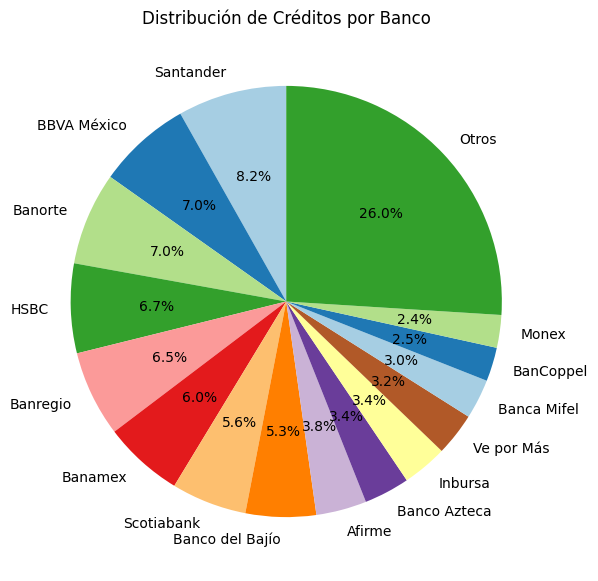

In [132]:
banco_counts = df_final['Nombre Institución'].value_counts()
top_15_bancos = banco_counts.head(15)
otros_bancos = banco_counts.tail(banco_counts.shape[0] - 15).sum()
top_bancos = pd.concat([top_15_bancos, pd.Series({'Otros': otros_bancos})])
plt.figure(figsize=(10, 7))
top_bancos.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Distribución de Créditos por Banco')
plt.ylabel('')  # No mostrar etiqueta en el eje Y
plt.show()

In [133]:
df_final.value_counts('Calificacion Riesgo')

,count
Calificacion Riesgo,
Riesgo A-1,27025
Riesgo D,18708
Riesgo A-2,17958
Riesgo E,17468
Riesgo C-1,14716
Riesgo B-3,14179
Riesgo B-1,13950
Riesgo C-2,13605
Riesgo B-2,12011


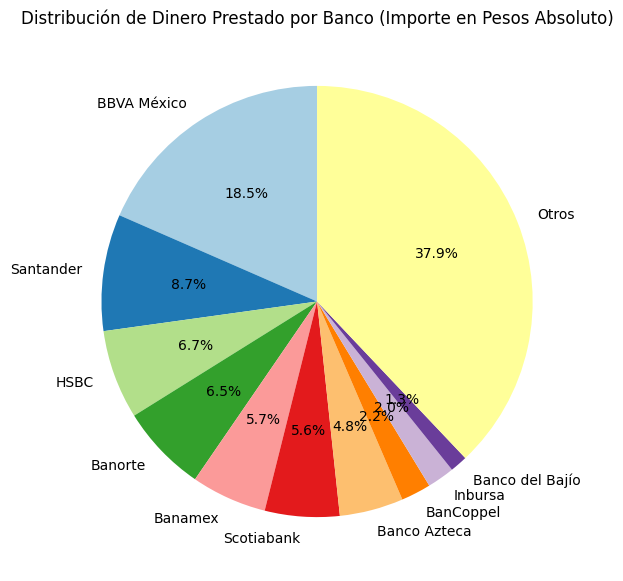

In [139]:
banco_importe = df_final.groupby('Nombre Institución')['Importe Pesos'].sum()
banco_importe = banco_importe.abs()
top_10_bancos_importe = banco_importe.sort_values(ascending=False).head(10)
otros_bancos_importe = banco_importe.tail(banco_importe.shape[0] - 10).sum()

# 5. Creamos una nueva serie con los top 10 y el total de los demás bancos
top_bancos_importe = pd.concat([top_10_bancos_importe, pd.Series({'Otros': otros_bancos_importe})])

# 6. Creamos el gráfico de pastel con el importe en pesos (ahora en valores absolutos)
plt.figure(figsize=(10, 7))
top_bancos_importe.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# Título y personalización
plt.title('Distribución de Dinero Prestado por Banco (Importe en Pesos Absoluto)')
plt.ylabel('')  # No mostrar etiqueta en el eje Y
plt.show()

<Figure size 1500x1500 with 0 Axes>

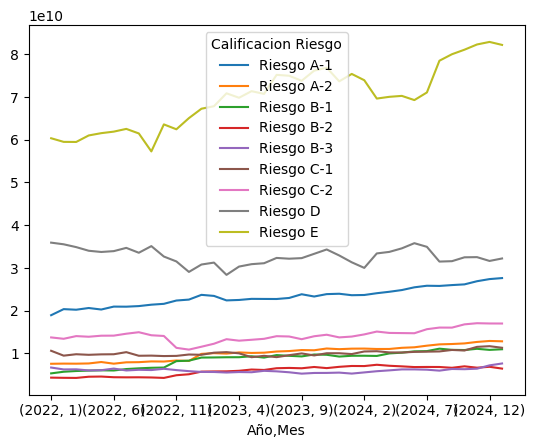

In [140]:
plt.figure(figsize=(15,15))
df_final.groupby(['Año', 'Mes', 'Calificacion Riesgo'])['Importe Pesos'].sum().unstack().plot()
plt.show()

In [141]:
import seaborn as sns

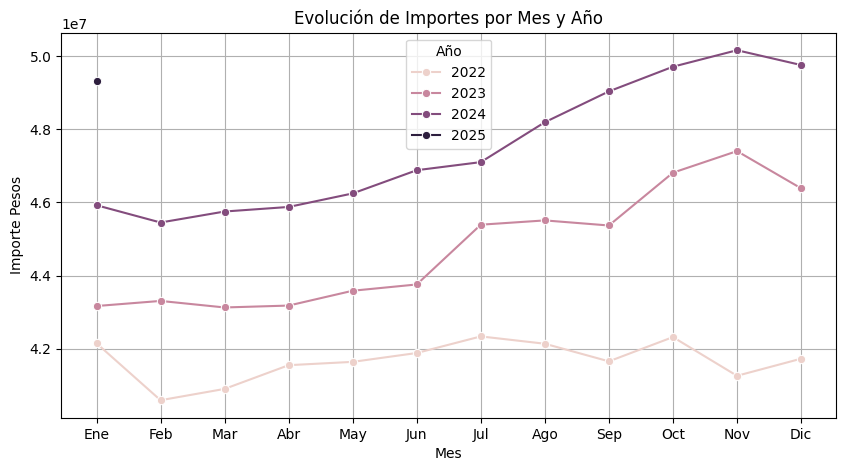

In [142]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_final,
    x='Mes',
    y='Importe Pesos',
    hue='Año',
    marker='o',
    errorbar=None
)

plt.title('Evolución de Importes por Mes y Año')
plt.xlabel('Mes')
plt.ylabel('Importe Pesos')
plt.grid(True)
plt.legend(title='Año')
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
plt.xticks(range(1, 13), meses)

plt.show()

Evolución del Importe Total por Mes/Año para cada Institución/Grupo

In [143]:
top_bancos = df_final.groupby('Nombre Institución')['Importe Pesos'].sum().abs().nlargest(10).index

# Filtrar y preparar datos
df_top = df_final[df_final['Nombre Institución'].isin(top_bancos)].copy()
df_top['Fecha'] = pd.to_datetime(df_top['Año'].astype(str) + '-' + df_top['Mes'].astype(str))
fig = px.line(
    df_top.groupby(['Fecha', 'Nombre Institución'], as_index=False)['Importe Pesos'].sum(),
    x='Fecha',
    y='Importe Pesos',
    color='Nombre Institución',
    title='Evolución Mensual - Top 10 Bancos (por volumen absoluto)',
    labels={'Importe Pesos': 'Importe (millones)', 'Fecha': 'Periodo'},
    height=600
)

fig.update_yaxes(tickprefix="$", tickformat=",.0f")
fig.update_layout(hovermode='x unified')
fig.show()

In [144]:
etiquetas = df_final['Calificacion Riesgo'].value_counts().index
valor = df_final['Calificacion Riesgo'].value_counts().values

df_riesgo = pd.DataFrame({
    'Calificacion': etiquetas,
    'Cantidad': valor
})


orden_riesgo = ['Riesgo A-1', 'Riesgo A-2', 'Riesgo B-1', 'Riesgo B-2', 'Riesgo B-3','Riesgo C-1'
               'Riesgo C-2', 'Riesgo D', 'Riesgo E']
df_riesgo['Calificacion'] = pd.Categorical(df_riesgo['Calificacion'], categories=orden_riesgo, ordered=True)
df_riesgo = df_riesgo.sort_values('Calificacion')


fig = px.bar(df_riesgo,
             x='Calificacion',
             y='Cantidad',
             color='Calificacion',
             color_discrete_sequence=px.colors.sequential.YlOrRd_r,
             title='Distribución de Calificaciones de Riesgo en la Cartera',
             labels={'Cantidad': 'Número de Créditos', 'Calificacion': 'Calificación de Riesgo'},
             text='Cantidad')

# Personalizar el gráfico
fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(
    xaxis_title="Calificación de Riesgo",
    yaxis_title="Cantidad de Créditos",
    showlegend=False,
    plot_bgcolor='rgba(0,0,0,0)',
    xaxis={'type': 'category'},
    hovermode="x unified"
)
fig.show()

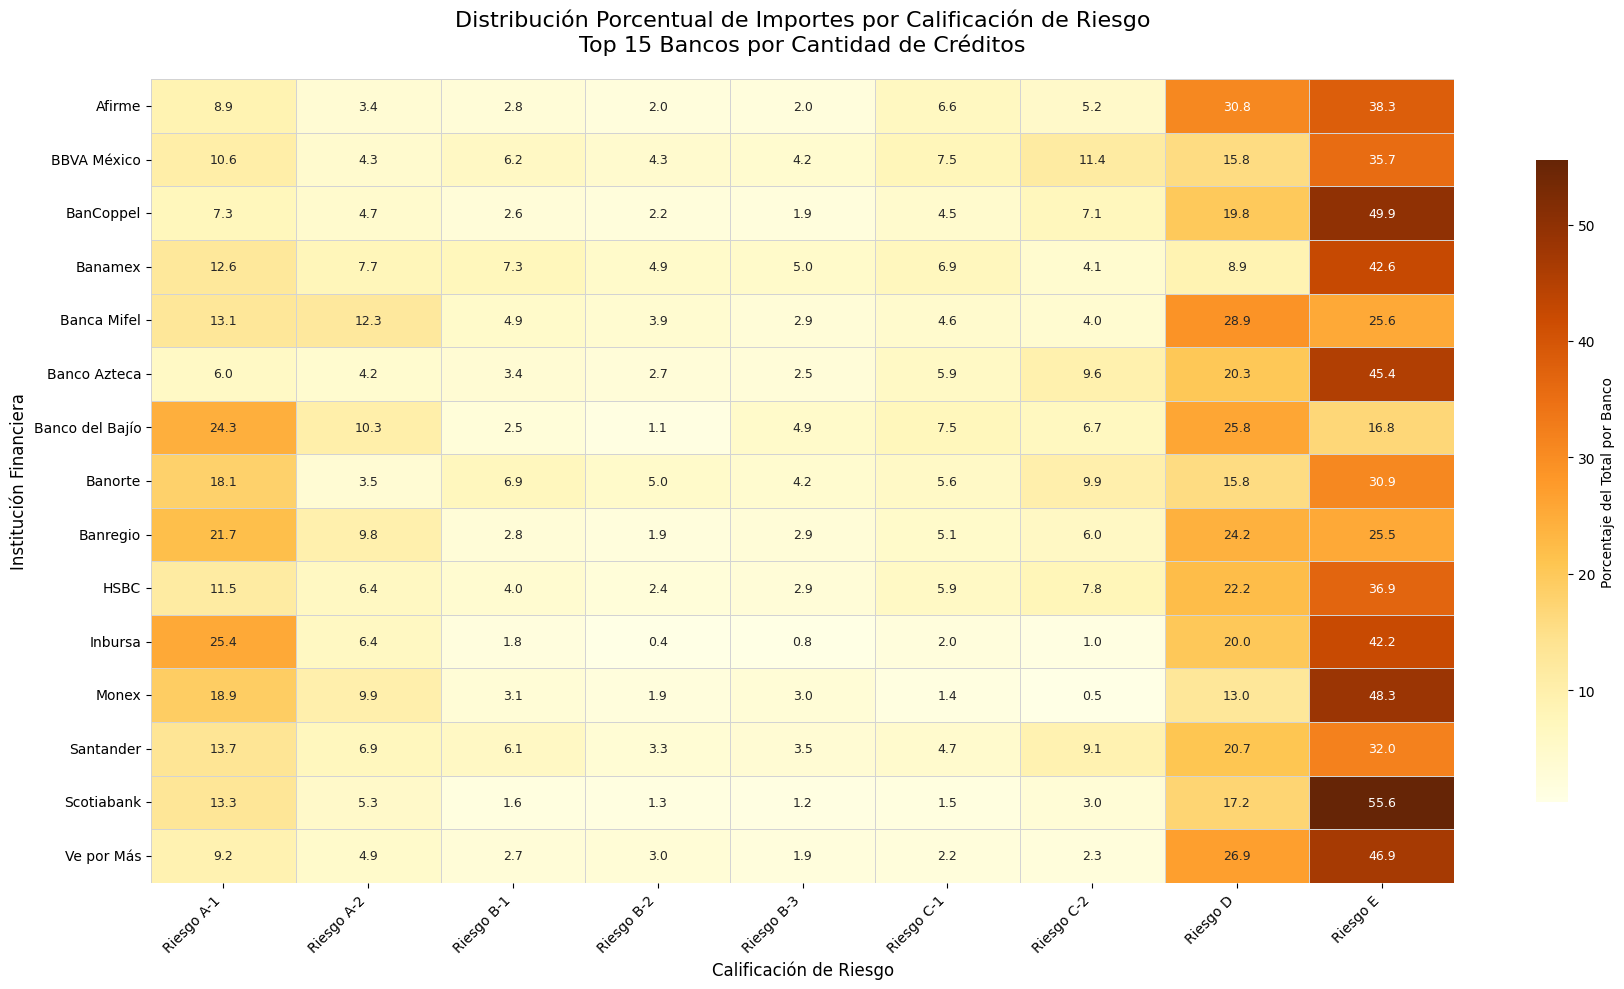

In [145]:
top_15_bancos = df_final['Nombre Institución'].value_counts().nlargest(15).index

df_top15 = df_final[df_final['Nombre Institución'].isin(top_15_bancos)].copy()

df_riesgo_top15 = df_top15.groupby(
    ['Nombre Institución', 'Calificacion Riesgo'],
    as_index=False
)['Importe Pesos'].sum()

pivot_top15 = df_riesgo_top15.pivot_table(
    index='Nombre Institución',
    columns='Calificacion Riesgo',
    values='Importe Pesos'
).fillna(0)

orden_riesgo = ['Riesgo A-1', 'Riesgo A-2', 'Riesgo B-1', 'Riesgo B-2', 'Riesgo B-3', 'Riesgo C-1',
               'Riesgo C-2', 'Riesgo D', 'Riesgo E']

categorias_existentes = [c for c in orden_riesgo if c in pivot_top15.columns]
pivot_percent = pivot_top15[categorias_existentes].div(pivot_top15[categorias_existentes].sum(axis=1), axis=0) * 100

plt.figure(figsize=(18, 10))
sns.heatmap(
    pivot_percent,
    annot=True,
    fmt='.1f',
    cmap='YlOrBr',
    linewidths=0.5,
    linecolor='lightgray',
    cbar_kws={'label': 'Porcentaje del Total por Banco', 'shrink': 0.8},
    annot_kws={'size': 9}
)

plt.title('Distribución Porcentual de Importes por Calificación de Riesgo\nTop 15 Bancos por Cantidad de Créditos',
          fontsize=16, pad=20)
plt.xlabel('Calificación de Riesgo', fontsize=12)
plt.ylabel('Institución Financiera', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

ax = plt.gca()
ax.set_yticklabels(ax.get_yticklabels(), va='center')
plt.tight_layout()
plt.show()

In [146]:
df_final.columns


Index(['Año', 'Mes', 'Nombre Institución', 'Nombre Grupo', 'Importe Pesos',
       'Etapa Riesgo', 'Tipo Operacion', 'Clase Credito', 'Subclase Credito',
       'Especificacion Producto', 'Calificacion Riesgo', 'Piso Minimo'],
      dtype='object')

In [147]:
# Contar cuántos créditos hay por banco y calificación de riesgo
df_riesgo = df_final.groupby(['Nombre Institución', 'Calificacion Riesgo']).size().reset_index(name='Cantidad Créditos')

df_pivot = df_riesgo.pivot_table(index='Nombre Institución',
                                 columns='Calificacion Riesgo',
                                 values='Cantidad Créditos',
                                 fill_value=0)


df_pivot['Total Créditos Banco'] = df_pivot.sum(axis=1)

df_banco = df_pivot.sort_values('Total Créditos Banco', ascending=False).reset_index()

In [148]:
df_riesgo.head(3)

,Nombre Institución,Calificacion Riesgo,Cantidad Créditos
0,Actinver,Riesgo A-1,430
1,Actinver,Riesgo A-2,317
2,Actinver,Riesgo B-1,256


In [149]:

df_banco = df_riesgo.pivot_table(
    index='Nombre Institución',
    columns='Calificacion Riesgo',
    values='Cantidad Créditos',
    fill_value=0
)

df_banco['Total Créditos Banco'] = df_banco.sum(axis=1)


df_banco = df_banco.reset_index()

In [150]:
df_banco.head(3)

Calificacion Riesgo,Nombre Institución,Riesgo A-1,Riesgo A-2,Riesgo B-1,Riesgo B-2,Riesgo B-3,Riesgo C-1,Riesgo C-2,Riesgo D,Riesgo E,Total Créditos Banco
0,Actinver,430.0,317.0,256.0,244.0,236.0,232.0,219.0,363.0,405.0,2702.0
1,Afirme,857.0,529.0,453.0,461.0,495.0,607.0,657.0,841.0,766.0,5666.0
2,Autofin,231.0,213.0,232.0,230.0,239.0,254.0,297.0,291.0,332.0,2319.0


In [151]:

for col in df_banco.columns:
    if col != 'Nombre Institución' and col != 'Total Créditos Banco':
        df_banco[col + ' (%)'] = (df_banco[col] / df_banco['Total Créditos Banco']) * 100

df_banco.head()


Calificacion Riesgo,Nombre Institución,Riesgo A-1,Riesgo A-2,Riesgo B-1,Riesgo B-2,Riesgo B-3,Riesgo C-1,Riesgo C-2,Riesgo D,Riesgo E,Total Créditos Banco,Riesgo A-1 (%),Riesgo A-2 (%),Riesgo B-1 (%),Riesgo B-2 (%),Riesgo B-3 (%),Riesgo C-1 (%),Riesgo C-2 (%),Riesgo D (%),Riesgo E (%)
0,Actinver,430.0,317.0,256.0,244.0,236.0,232.0,219.0,363.0,405.0,2702.0,15.914138,11.732050,9.474463,9.030348,8.734271,8.586232,8.105107,13.434493,14.988897
1,Afirme,857.0,529.0,453.0,461.0,495.0,607.0,657.0,841.0,766.0,5666.0,15.125309,9.336393,7.995058,8.136251,8.736322,10.713025,11.595482,14.842923,13.519238
2,Autofin,231.0,213.0,232.0,230.0,239.0,254.0,297.0,291.0,332.0,2319.0,9.961190,9.184994,10.004312,9.918068,10.306166,10.952997,12.807245,12.548512,14.316516
3,BBVA México,1872.0,1225.0,1018.0,860.0,1184.0,1166.0,921.0,1176.0,1082.0,10504.0,17.821782,11.662224,9.691546,8.187357,11.271896,11.100533,8.768088,11.195735,10.300838
4,BIAfirme,47.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54.0,87.037037,12.962963,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [152]:
percentage_cols = [col for col in df_banco.columns if '(' in col]
df_banco = df_banco[['Nombre Institución'] + percentage_cols]
df_banco.head()


Calificacion Riesgo,Nombre Institución,Riesgo A-1 (%),Riesgo A-2 (%),Riesgo B-1 (%),Riesgo B-2 (%),Riesgo B-3 (%),Riesgo C-1 (%),Riesgo C-2 (%),Riesgo D (%),Riesgo E (%)
0,Actinver,15.914138,11.732050,9.474463,9.030348,8.734271,8.586232,8.105107,13.434493,14.988897
1,Afirme,15.125309,9.336393,7.995058,8.136251,8.736322,10.713025,11.595482,14.842923,13.519238
2,Autofin,9.961190,9.184994,10.004312,9.918068,10.306166,10.952997,12.807245,12.548512,14.316516
3,BBVA México,17.821782,11.662224,9.691546,8.187357,11.271896,11.100533,8.768088,11.195735,10.300838
4,BIAfirme,87.037037,12.962963,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [153]:
def clasificar_banco(row):
    bajo_riesgo = row['Riesgo A-1 (%)'] + row['Riesgo A-2 (%)']
    riesgo_alto = (
        row['Riesgo C-1 (%)'] +
        row['Riesgo C-2 (%)'] +
        row['Riesgo D (%)'] +
        row['Riesgo E (%)']
    )

    if bajo_riesgo >= 60:
        return 'Bajo riesgo'
    elif riesgo_alto >= 40:
        return 'Alto riesgo'
    else:
        return 'Riesgo moderado'

df_banco['Clasificación'] = df_banco.apply(clasificar_banco, axis=1)

In [154]:
df_banco.head(3)

Calificacion Riesgo,Nombre Institución,Riesgo A-1 (%),Riesgo A-2 (%),Riesgo B-1 (%),Riesgo B-2 (%),Riesgo B-3 (%),Riesgo C-1 (%),Riesgo C-2 (%),Riesgo D (%),Riesgo E (%),Clasificación
0,Actinver,15.914138,11.732050,9.474463,9.030348,8.734271,8.586232,8.105107,13.434493,14.988897,Alto riesgo
1,Afirme,15.125309,9.336393,7.995058,8.136251,8.736322,10.713025,11.595482,14.842923,13.519238,Alto riesgo
2,Autofin,9.961190,9.184994,10.004312,9.918068,10.306166,10.952997,12.807245,12.548512,14.316516,Alto riesgo


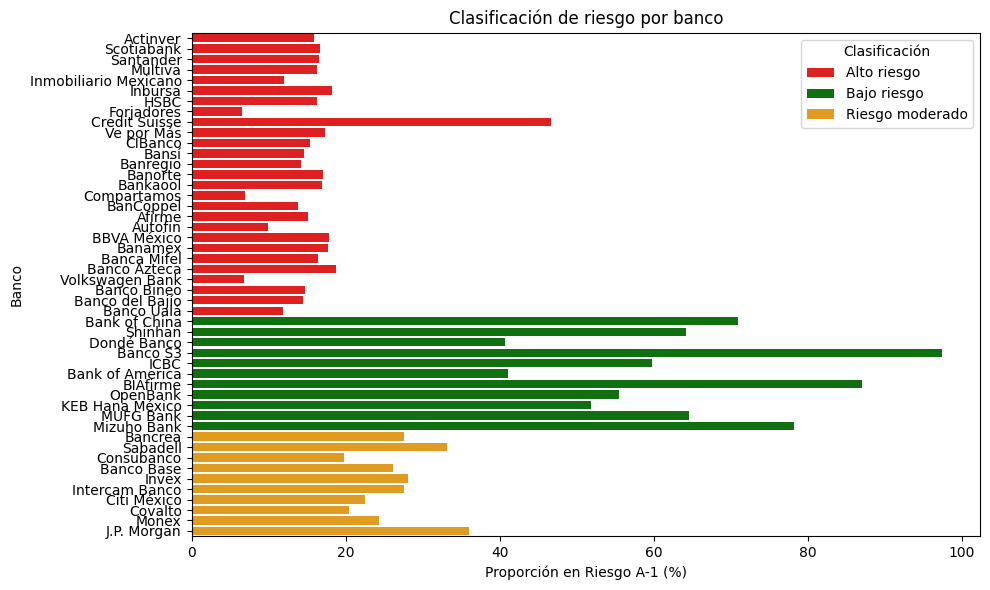

In [155]:

df_banco_sorted = df_banco.sort_values('Clasificación')

plt.figure(figsize=(10, 6))


sns.barplot(
    data=df_banco_sorted,
    y='Nombre Institución',
    x='Riesgo A-1 (%)',
    hue='Clasificación',
    dodge=False,
    palette={'Bajo riesgo': 'green', 'Riesgo moderado': 'orange', 'Alto riesgo': 'red'}
)


plt.xlabel('Proporción en Riesgo A-1 (%)')
plt.ylabel('Banco')
plt.title('Clasificación de riesgo por banco')
plt.legend(title='Clasificación')
plt.tight_layout()

plt.show()